In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [84]:
test_df = pd.read_csv(r"E:\APU_Predictive_Maintenance\Artifacts\Data_split\Test_datasets\test_dataset.csv")
test_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target
0,2,1,0.0025,0.0,100.0,518.67,642.04,1588.910000,1404.3,14.62,...,0.03,393,2388,100.0,38.88,23.2326,0.015673,0,healthy,none
1,2,1,0.0025,0.0,100.0,518.67,642.04,1588.910000,1404.3,14.62,...,0.03,393,2388,100.0,38.88,23.2326,0.015673,1,gradual_drift,sensor_2|sensor_7
2,2,1,0.0025,0.0,100.0,518.67,642.04,1588.910000,1404.3,14.62,...,0.03,393,2388,100.0,38.88,23.2326,0.015673,2,bias_shift,sensor_4|sensor_8
3,2,1,0.0025,0.0,100.0,518.67,642.04,1502.413383,1404.3,14.62,...,0.03,393,2388,100.0,38.88,23.2326,0.027683,3,noise_increase,sensor_3
4,2,1,0.0025,0.0,100.0,518.67,642.04,1588.910000,1404.3,14.62,...,0.03,393,2388,100.0,38.88,23.2326,0.015673,4,spike,sensor_9


In [85]:
train_df = pd.read_csv(r"E:\APU_Predictive_Maintenance\Artifacts\Data_split\Train_datasets\train_dataset.csv")
train_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target
0,1,1,34.9983,0.84,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.0,14.73,8.8071,-0.019345,0,healthy,none
1,1,1,34.9983,0.84,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.0,14.73,8.8071,-0.019345,1,gradual_drift,sensor_2|sensor_7
2,1,1,34.9983,0.84,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.0,14.73,8.8071,-0.019345,2,bias_shift,sensor_4|sensor_8
3,1,1,34.9983,0.84,100.0,449.44,555.32,1557.855816,1137.23,5.48,...,0.02,334,2223,100.0,14.73,8.8071,0.003828,3,noise_increase,sensor_3
4,1,1,34.9983,0.84,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.0,14.73,8.8071,-0.019345,4,spike,sensor_9


In [86]:
train_df.shape, test_df.shape

((257334, 30), (65220, 30))

In [87]:
raw_df = pd.read_csv(r"E:\APU_Predictive_Maintenance\Artifacts\Fault_injected_data\Fault_injection_dataset.csv")
raw_df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,0,healthy,none
1,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,0,healthy,none
2,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,0.02,309,1915,84.93,14.08,8.6723,0.093239,0,healthy,none
3,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,0.02,329,2212,100.00,10.59,6.4701,-0.027757,0,healthy,none
4,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,0.02,309,1915,84.93,14.13,8.5286,0.032798,0,healthy,none


In [88]:
raw_df.shape

(322554, 30)

In [89]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257334 entries, 0 to 257333
Data columns (total 30 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   engine_id      257334 non-null  int64  
 1   cycle          257334 non-null  int64  
 2   op_setting_1   257334 non-null  float64
 3   op_setting_2   257334 non-null  float64
 4   op_setting_3   257334 non-null  float64
 5   sensor_1       257334 non-null  float64
 6   sensor_2       257334 non-null  float64
 7   sensor_3       257334 non-null  float64
 8   sensor_4       257334 non-null  float64
 9   sensor_5       257334 non-null  float64
 10  sensor_6       257334 non-null  float64
 11  sensor_7       257334 non-null  float64
 12  sensor_8       257334 non-null  float64
 13  sensor_9       257334 non-null  float64
 14  sensor_10      257334 non-null  float64
 15  sensor_11      257334 non-null  float64
 16  sensor_12      257334 non-null  float64
 17  sensor_13      257334 non-nul

In [90]:
train_df.describe()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label
count,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,...,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000,257334.000000
mean,128.890368,108.496677,23.992853,0.572015,94.057217,472.912806,583.095562,1420.045873,1207.100862,8.032980,...,8066.978329,9.329044,0.023324,348.330411,2228.908345,97.761057,20.792934,12.475959,0.008815,2.500000
std,74.488922,68.446253,14.742902,0.310006,14.226575,26.382707,38.208045,138.891075,119.220923,3.612354,...,84.857505,0.748944,0.004711,27.742049,145.228059,5.359862,9.865252,5.919112,0.043349,1.707828
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.530000,154.032481,1023.770000,3.910000,...,7848.360000,8.335700,0.020000,303.000000,1915.000000,84.930000,10.190000,6.010500,-0.085118,0.000000
25%,67.000000,52.000000,10.004700,0.250600,100.000000,449.440000,549.660000,1351.282500,1123.970000,5.480000,...,8062.320000,8.677700,0.020000,331.000000,2212.000000,100.000000,13.940000,8.360500,-0.024054,1.000000
50%,128.000000,104.000000,25.001300,0.700000,100.000000,462.540000,556.650000,1371.240000,1142.650000,7.050000,...,8082.840000,9.310800,0.020000,335.000000,2223.000000,100.000000,14.880000,8.929700,0.005673,2.500000
75%,191.000000,156.000000,35.008000,0.840000,100.000000,491.190000,607.700000,1501.420000,1307.200000,10.520000,...,8127.500000,9.386700,0.030000,369.000000,2324.000000,100.000000,28.470000,17.083400,0.038471,4.000000
max,259.000000,378.000000,42.008000,0.842000,100.000000,518.670000,644.520000,2486.831634,1460.779666,14.620000,...,8268.500000,11.066900,0.030000,399.000000,2388.000000,100.000000,39.270000,23.590100,0.170313,5.000000


In [91]:
train_df.sort_values(by=["engine_id", "cycle"])
train_df.head(20)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,0,healthy,none
1,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,1,gradual_drift,sensor_2|sensor_7
2,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,2,bias_shift,sensor_4|sensor_8
3,1,1,34.9983,0.8400,100.0,449.44,555.32,1557.855816,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,0.003828,3,noise_increase,sensor_3
4,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,4,spike,sensor_9
5,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,5,coupled_fault,sensor_11|sensor_12
6,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.220000,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,0,healthy,none
7,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.220000,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,1,gradual_drift,sensor_2|sensor_7
8,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.220000,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,2,bias_shift,sensor_4|sensor_8
9,1,2,41.9982,0.8408,100.0,445.00,549.90,1265.838399,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.022937,3,noise_increase,sensor_3


In [92]:
train_df = train_df.reset_index(drop=True)
train_df.head(20)

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,0,healthy,none
1,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,1,gradual_drift,sensor_2|sensor_7
2,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,2,bias_shift,sensor_4|sensor_8
3,1,1,34.9983,0.8400,100.0,449.44,555.32,1557.855816,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,0.003828,3,noise_increase,sensor_3
4,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,4,spike,sensor_9
5,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.610000,1137.23,5.48,...,0.02,334,2223,100.00,14.73,8.8071,-0.019345,5,coupled_fault,sensor_11|sensor_12
6,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.220000,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,0,healthy,none
7,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.220000,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,1,gradual_drift,sensor_2|sensor_7
8,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.220000,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.033990,2,bias_shift,sensor_4|sensor_8
9,1,2,41.9982,0.8408,100.0,445.00,549.90,1265.838399,1125.78,3.91,...,0.02,330,2212,100.00,10.41,6.2665,-0.022937,3,noise_increase,sensor_3


In [93]:
df = train_df.drop_duplicates(keep="first")



In [94]:
df = df.duplicated()
df.sum()

np.int64(0)

In [95]:
df = train_df.drop_duplicates(subset=["engine_id", "cycle"])

In [96]:
max_cycle = df.groupby('engine_id')['cycle'].max()
max_cycle


engine_id
1      149
3      206
4      235
5      154
6      175
      ... 
254    260
255    340
257    309
258    143
259    205
Name: cycle, Length: 208, dtype: int64

In [97]:
df["max_cycle"] = df["engine_id"].map(max_cycle)
df.head(20)

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_30320\3474288433.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["max_cycle"] = df["engine_id"].map(max_cycle)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target,max_cycle
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,334,2223,100.00,14.73,8.8071,-0.019345,0,healthy,none,149
6,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,330,2212,100.00,10.41,6.2665,-0.033990,0,healthy,none,149
12,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,309,1915,84.93,14.08,8.6723,0.093239,0,healthy,none,149
18,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,329,2212,100.00,10.59,6.4701,-0.027757,0,healthy,none,149
24,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,309,1915,84.93,14.13,8.5286,0.032798,0,healthy,none,149
30,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,306,1915,84.93,14.28,8.5590,0.015076,0,healthy,none,149
36,1,7,42.0043,0.8409,100.0,445.00,549.74,1347.45,1127.19,3.91,...,330,2212,100.00,10.62,6.4227,-0.052934,0,healthy,none,149
42,1,8,20.0020,0.7002,100.0,491.19,607.44,1481.69,1252.36,9.35,...,365,2324,100.00,24.33,14.7989,0.009287,0,healthy,none,149
48,1,9,41.9995,0.8407,100.0,445.00,549.33,1348.23,1127.45,3.91,...,331,2212,100.00,10.69,6.3802,-0.033681,0,healthy,none,149
54,1,10,42.0011,0.8400,100.0,445.00,549.33,1356.40,1127.11,3.91,...,329,2212,100.00,10.57,6.2847,-0.047740,0,healthy,none,149


In [98]:
df['RUL'] = df['max_cycle'] - df['cycle']
df

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_30320\2611634284.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RUL'] = df['max_cycle'] - df['cycle']


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target,max_cycle,RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2223,100.00,14.73,8.8071,-0.019345,0,healthy,none,149,148
6,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2212,100.00,10.41,6.2665,-0.033990,0,healthy,none,149,147
12,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,1915,84.93,14.08,8.6723,0.093239,0,healthy,none,149,146
18,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2212,100.00,10.59,6.4701,-0.027757,0,healthy,none,149,145
24,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,1915,84.93,14.13,8.5286,0.032798,0,healthy,none,149,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257304,259,201,20.0070,0.7000,100.0,491.19,608.51,1496.24,1274.58,9.35,...,2324,100.00,24.24,14.4662,0.057721,0,healthy,none,205,4
257310,259,202,42.0076,0.8400,100.0,445.00,550.35,1370.37,1140.60,3.91,...,2212,100.00,10.65,6.3241,-0.000508,0,healthy,none,205,3
257316,259,203,25.0074,0.6200,60.0,462.54,537.04,1276.86,1062.90,7.05,...,1915,84.93,14.22,8.4417,0.063921,0,healthy,none,205,2
257322,259,204,25.0042,0.6200,60.0,462.54,537.07,1277.35,1069.60,7.05,...,1915,84.93,14.06,8.4913,0.090262,0,healthy,none,205,1


In [99]:
val = 140
df['RUL'] = df['RUL'].clip(upper=val)
print(df[["engine_id", "cycle", "max_cycle", "RUL"]].head(15))

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_30320\3729858662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RUL'] = df['RUL'].clip(upper=val)


    engine_id  cycle  max_cycle  RUL
0           1      1        149  140
6           1      2        149  140
12          1      3        149  140
18          1      4        149  140
24          1      5        149  140
30          1      6        149  140
36          1      7        149  140
42          1      8        149  140
48          1      9        149  140
54          1     10        149  139
60          1     11        149  138
66          1     12        149  137
72          1     13        149  136
78          1     14        149  135
84          1     15        149  134


In [100]:
df.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,anomaly_score,fault_label,fault_type,fault_target,max_cycle,RUL
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,2223,100.00,14.73,8.8071,-0.019345,0,healthy,none,149,140
6,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,2212,100.00,10.41,6.2665,-0.033990,0,healthy,none,149,140
12,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,1915,84.93,14.08,8.6723,0.093239,0,healthy,none,149,140
18,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,2212,100.00,10.59,6.4701,-0.027757,0,healthy,none,149,140
24,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,1915,84.93,14.13,8.5286,0.032798,0,healthy,none,149,140


In [101]:
sensor_cols = [col for col in df.columns if "sensor" in col]

for col in sensor_cols:
    df[f"{col}_roll_mean"] = df.groupby("engine_id")[col].rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
    df[f"{col}_roll_std"] = df.groupby("engine_id")[col].rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
    df.fillna(0, inplace=True)

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_30320\2550116953.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_roll_mean"] = df.groupby("engine_id")[col].rolling(window=5, min_periods=1).mean().reset_index(0, drop=True)
C:\Users\Hareesh\AppData\Local\Temp\ipykernel_30320\2550116953.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"{col}_roll_std"] = df.groupby("engine_id")[col].rolling(window=5, min_periods=1).std().reset_index(0, drop=True)
C:\Users\Hareesh\AppData\Local\Temp\ipykerne

In [102]:
df.head(20)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_17_roll_mean,sensor_17_roll_std,sensor_18_roll_mean,sensor_18_roll_std,sensor_19_roll_mean,sensor_19_roll_std,sensor_20_roll_mean,sensor_20_roll_std,sensor_21_roll_mean,sensor_21_roll_std
0,1,1,34.9983,0.8400,100.0,449.44,555.32,1358.61,1137.23,5.48,...,334.000000,0.000000,2223.000000,0.000000,100.000000,0.000000,14.730000,0.000000,8.80710,0.000000
6,1,2,41.9982,0.8408,100.0,445.00,549.90,1353.22,1125.78,3.91,...,332.000000,2.828427,2217.500000,7.778175,100.000000,0.000000,12.570000,3.054701,7.53680,1.796475
12,1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,...,324.333333,13.428825,2116.666667,174.735038,94.976667,8.700669,13.073333,2.329299,7.91530,1.429493
18,1,4,42.0077,0.8416,100.0,445.00,549.51,1354.03,1126.38,3.91,...,325.500000,11.210114,2140.500000,150.422738,96.232500,7.535000,12.452500,2.271305,7.55400,1.372753
24,1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,...,322.200000,12.194261,2095.400000,164.743133,93.972000,8.254179,12.788000,2.105213,7.74892,1.266217
30,1,6,25.0045,0.6205,60.0,462.54,537.02,1266.38,1048.72,7.05,...,316.600000,11.844830,2033.800000,162.673600,90.958000,8.254179,12.698000,2.008848,7.69930,1.218339
36,1,7,42.0043,0.8409,100.0,445.00,549.74,1347.45,1127.19,3.91,...,316.600000,11.844830,2033.800000,162.673600,90.958000,8.254179,12.740000,1.950397,7.73054,1.173596
42,1,8,20.0020,0.7002,100.0,491.19,607.44,1481.69,1252.36,9.35,...,327.800000,23.552070,2115.600000,188.744007,93.972000,8.254179,14.790000,5.628859,8.95586,3.430637
48,1,9,41.9995,0.8407,100.0,445.00,549.33,1348.23,1127.45,3.91,...,328.200000,23.594491,2115.600000,188.744007,93.972000,8.254179,14.810000,5.610352,8.93788,3.447117
54,1,10,42.0011,0.8400,100.0,445.00,549.33,1356.40,1127.11,3.91,...,332.200000,21.087911,2175.000000,153.222061,96.986000,6.739509,14.098000,5.934743,8.48910,3.653605


In [103]:
df.columns

Index(['engine_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'anomaly_score', 'fault_label', 'fault_type', 'fault_target',
       'max_cycle', 'RUL', 'sensor_1_roll_mean', 'sensor_1_roll_std',
       'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean',
       'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std',
       'sensor_5_roll_mean', 'sensor_5_roll_std', 'sensor_6_roll_mean',
       'sensor_6_roll_std', 'sensor_7_roll_mean', 'sensor_7_roll_std',
       'sensor_8_roll_mean', 'sensor_8_roll_std', 'sensor_9_roll_mean',
       'sensor_9_roll_std', 'sensor_10_roll_mean', 'sensor_10_roll_std',
       'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_1

In [104]:
sensor_cols = [col for col in df.columns if "sensor_" in col]

X = df[sensor_cols]

In [105]:
X = X.fillna(method="ffill")

C:\Users\Hareesh\AppData\Local\Temp\ipykernel_30320\656806923.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method="ffill")


In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [107]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [108]:
import numpy as np

explained_var = np.cumsum(pca.explained_variance_ratio_)
print(explained_var)

[0.44545941 0.67491355 0.84114615 0.91623594 0.95576881 0.96997919
 0.97901286 0.98523035 0.98883955 0.99160184 0.99382635 0.99584036
 0.9968617  0.99762066 0.99817663 0.99861349 0.99895461 0.99919491
 0.99941404 0.99950566 0.99957423 0.99963775 0.99969659 0.9997457
 0.99978428 0.99981577 0.99984434 0.99986967 0.99989291 0.99991017
 0.9999224  0.99993366 0.99994398 0.9999531  0.99996159 0.99996887
 0.99997501 0.99997977 0.99998382 0.99998781 0.99999051 0.99999286
 0.99999427 0.99999538 0.99999648 0.99999745 0.99999834 0.99999894
 0.99999931 0.99999954 0.99999973 0.99999987 0.99999993 0.99999996
 0.99999997 0.99999998 0.99999999 0.99999999 1.         1.
 1.         1.         1.        ]


In [113]:
pca = PCA(n_components=0.75)
X_pca = pca.fit_transform(X_scaled)

In [117]:
pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)

df_pca.head()


,PC1,PC2,PC3
0,-7.791708,-11.046899,0.781779
1,-8.016168,-9.947130,0.001000
2,-12.120473,-1.080449,1.895865
3,-9.876746,-4.230570,3.123987
4,-12.624763,-1.222585,2.247631


In [115]:
final_df = pd.concat([df_pca, df["RUL"].reset_index(drop=True)], axis=1)

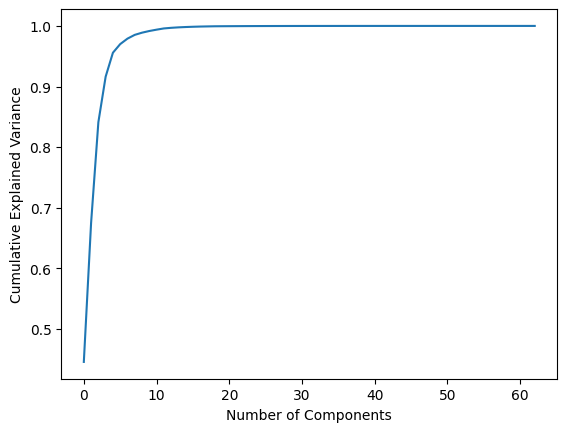

In [116]:
import matplotlib.pyplot as plt

plt.plot(explained_var)
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

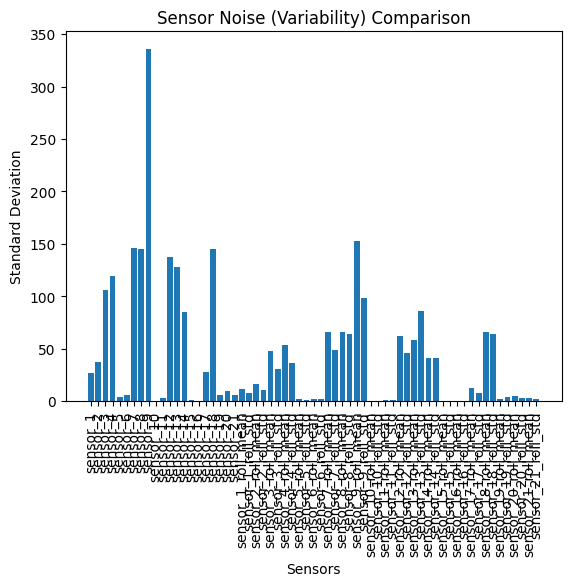

In [118]:
import matplotlib.pyplot as plt

# select sensor columns
sensor_cols = [col for col in df.columns if "sensor_" in col]

# compute standard deviation (noise level)
std_values = df[sensor_cols].std()

# plot
plt.figure()
plt.bar(sensor_cols, std_values)
plt.xticks(rotation=90)
plt.xlabel("Sensors")
plt.ylabel("Standard Deviation")
plt.title("Sensor Noise (Variability) Comparison")
plt.show()

In [119]:
import matplotlib.pyplot as plt

sensor_columns = [
    'sensor_2','sensor_3','sensor_4','sensor_7','sensor_8',
    'sensor_9','sensor_11','sensor_12','sensor_13','sensor_14',
    'sensor_15','sensor_17','sensor_20','sensor_21'
]

# Calculate standard deviation
std_values = df[sensor_columns].std().sort_values(ascending=False)

print(std_values)


sensor_9     335.694000
sensor_7     145.947828
sensor_8     145.109325
sensor_12    137.604685
sensor_13    127.968179
sensor_4     119.068008
sensor_3     105.888289
sensor_14     84.858330
sensor_2      37.274648
sensor_17     27.742318
sensor_20      9.865347
sensor_21      5.919169
sensor_11      3.230473
sensor_15      0.748951
dtype: float64


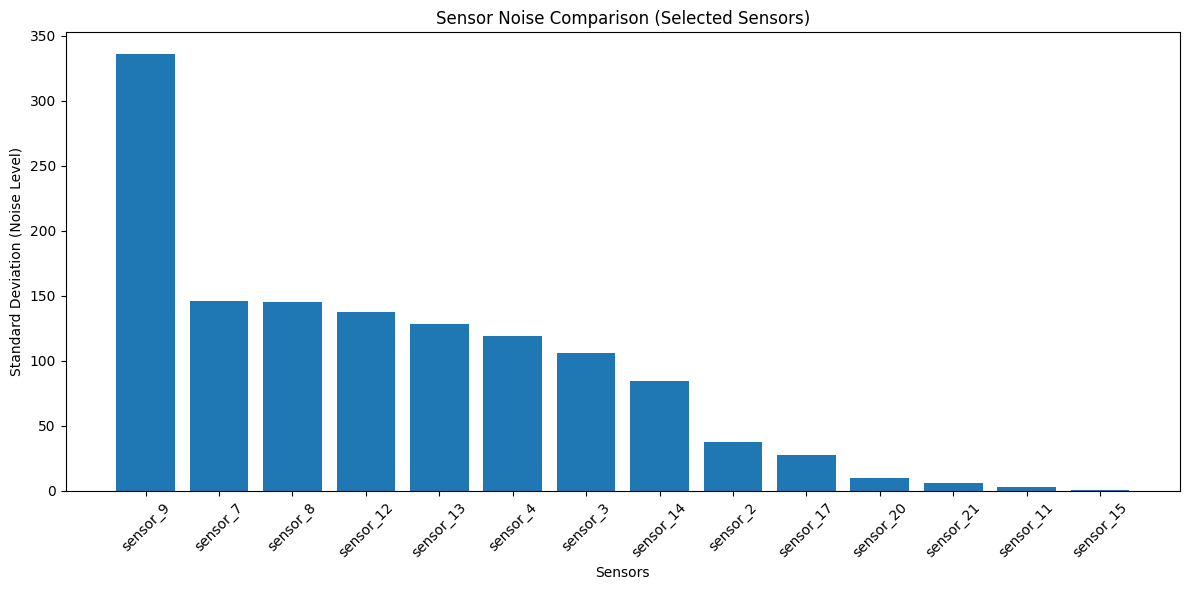

In [120]:
plt.figure(figsize=(12,6))
plt.bar(std_values.index, std_values.values)
plt.xticks(rotation=45)
plt.xlabel("Sensors")
plt.ylabel("Standard Deviation (Noise Level)")
plt.title("Sensor Noise Comparison (Selected Sensors)")
plt.tight_layout()
plt.show()
